1. Chargement et préparation des données

**texte en gras**

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Colab PySpark") \
    .getOrCreate()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ensemble-de-donnees-6a0a3f2316332589898898 (1).csv to ensemble-de-donnees-6a0a3f2316332589898898 (1).csv


In [ ]:
import os

os.listdir()

['.config',
 'ensemble-de-donnees-6a0a3f2316332589898898 (1).csv',
 'sample_data']

In [ ]:
df = spark.read.csv("ensemble-de-donnees-6a0a3f2316332589898898 (1).csv", header=True, inferSchema=True)

df.show(5)

+--------+---+------+----------+-------------+--------------+----+----+---+
|Match_ID|Div|Season|      Date|     HomeTeam|      AwayTeam|FTHG|FTAG|FTR|
+--------+---+------+----------+-------------+--------------+----+----+---+
|       1| D2|  2009|2010-04-04|   Oberhausen|Kaiserslautern|   2|   1|  H|
|       2| D2|  2009|2009-11-01|  Munich 1860|Kaiserslautern|   0|   1|  A|
|       3| D2|  2009|2009-10-04|Frankfurt FSV|Kaiserslautern|   1|   1|  D|
|       4| D2|  2009|2010-02-21|Frankfurt FSV|     Karlsruhe|   2|   1|  H|
|       5| D2|  2009|2009-12-06|        Ahlen|     Karlsruhe|   1|   3|  A|
+--------+---+------+----------+-------------+--------------+----+----+---+
only showing top 5 rows


In [ ]:
df = df.drop("Match_ID")
df.show()

+---+------+----------+------------------+--------------+----+----+---+
|Div|Season|      Date|          HomeTeam|      AwayTeam|FTHG|FTAG|FTR|
+---+------+----------+------------------+--------------+----+----+---+
| D2|  2009|2010-04-04|        Oberhausen|Kaiserslautern|   2|   1|  H|
| D2|  2009|2009-11-01|       Munich 1860|Kaiserslautern|   0|   1|  A|
| D2|  2009|2009-10-04|     Frankfurt FSV|Kaiserslautern|   1|   1|  D|
| D2|  2009|2010-02-21|     Frankfurt FSV|     Karlsruhe|   2|   1|  H|
| D2|  2009|2009-12-06|             Ahlen|     Karlsruhe|   1|   3|  A|
| D2|  2009|2010-04-03|      Union Berlin|     Karlsruhe|   1|   1|  D|
| D2|  2009|2009-08-14|         Paderborn|     Karlsruhe|   2|   0|  H|
| D2|  2009|2010-03-08|         Bielefeld|     Karlsruhe|   0|   1|  A|
| D2|  2009|2009-09-26|    Kaiserslautern|     Karlsruhe|   2|   0|  H|
| D2|  2009|2009-11-21|     Hansa Rostock|     Karlsruhe|   2|   1|  H|
| D2|  2009|2009-12-19|    Greuther Furth|     Karlsruhe|   1|  

In [ ]:
df = df.withColumnRenamed("FTHG", "HomeTeamGoal") \
       .withColumnRenamed("FTAG", "AwayTeamGoals") \
       .withColumnRenamed("FTR", "FinalResult")
df.show()

+---+------+----------+------------------+--------------+------------+-------------+-----------+
|Div|Season|      Date|          HomeTeam|      AwayTeam|HomeTeamGoal|AwayTeamGoals|FinalResult|
+---+------+----------+------------------+--------------+------------+-------------+-----------+
| D2|  2009|2010-04-04|        Oberhausen|Kaiserslautern|           2|            1|          H|
| D2|  2009|2009-11-01|       Munich 1860|Kaiserslautern|           0|            1|          A|
| D2|  2009|2009-10-04|     Frankfurt FSV|Kaiserslautern|           1|            1|          D|
| D2|  2009|2010-02-21|     Frankfurt FSV|     Karlsruhe|           2|            1|          H|
| D2|  2009|2009-12-06|             Ahlen|     Karlsruhe|           1|            3|          A|
| D2|  2009|2010-04-03|      Union Berlin|     Karlsruhe|           1|            1|          D|
| D2|  2009|2009-08-14|         Paderborn|     Karlsruhe|           2|            0|          H|
| D2|  2009|2010-03-08|       

**2 ) Création de colonnes supplémentaires**

In [ ]:
from pyspark.sql.functions import when, col

df = df.withColumn(
        "HomeTeamWin",
        when(col("FinalResult") == "H", 1).otherwise(0)
    ) \
    .withColumn(
        "AwayTeamWin",
        when(col("FinalResult") == "A", 1).otherwise(0)
    ) \
    .withColumn(
        "GameTie",
        when(col("FinalResult") == "D", 1).otherwise(0)
    )
df.show()

+---+------+----------+------------------+--------------+------------+-------------+-----------+-----------+-----------+-------+
|Div|Season|      Date|          HomeTeam|      AwayTeam|HomeTeamGoal|AwayTeamGoals|FinalResult|HomeTeamWin|AwayTeamWin|GameTie|
+---+------+----------+------------------+--------------+------------+-------------+-----------+-----------+-----------+-------+
| D2|  2009|2010-04-04|        Oberhausen|Kaiserslautern|           2|            1|          H|          1|          0|      0|
| D2|  2009|2009-11-01|       Munich 1860|Kaiserslautern|           0|            1|          A|          0|          1|      0|
| D2|  2009|2009-10-04|     Frankfurt FSV|Kaiserslautern|           1|            1|          D|          0|          0|      1|
| D2|  2009|2010-02-21|     Frankfurt FSV|     Karlsruhe|           2|            1|          H|          1|          0|      0|
| D2|  2009|2009-12-06|             Ahlen|     Karlsruhe|           1|            3|          A| 

**3. Filtrage des données**

In [ ]:
df_filtered = df.filter(
    (df.Div == "D1") &
    (df.Season >= 2000) &
    (df.Season <= 2015)
)
df_filtered.show()

+---+------+----------+-------------+----------+------------+-------------+-----------+-----------+-----------+-------+
|Div|Season|      Date|     HomeTeam|  AwayTeam|HomeTeamGoal|AwayTeamGoals|FinalResult|HomeTeamWin|AwayTeamWin|GameTie|
+---+------+----------+-------------+----------+------------+-------------+-----------+-----------+-----------+-------+
| D1|  2009|2010-02-06|       Bochum|Leverkusen|           1|            1|          D|          0|          0|      1|
| D1|  2009|2009-11-22|Bayern Munich|Leverkusen|           1|            1|          D|          0|          0|      1|
| D1|  2009|2010-05-08|   M'gladbach|Leverkusen|           1|            1|          D|          0|          0|      1|
| D1|  2009|2009-08-08|        Mainz|Leverkusen|           2|            2|          D|          0|          0|      1|
| D1|  2009|2009-10-17|      Hamburg|Leverkusen|           0|            0|          D|          0|          0|      1|
| D1|  2009|2010-04-17|    Stuttgart|Lev

**4. Agrégations avec Group By (voir ressources)**

**✈️⚽ df_home_matches**

In [ ]:
from pyspark.sql.functions import sum, count

df_home_matches = df_filtered.groupBy("Season", "HomeTeam").agg(
    count("*").alias("HomeMatches"),

    sum("HomeTeamWin").alias("TotalHomeWin"),
    sum(when(col("FinalResult") == "A", 1).otherwise(0)).alias("TotalHomeLoss"),
    sum("GameTie").alias("TotalHomeTie"),

    sum("HomeTeamGoal").alias("HomeScoredGoals"),
    sum("AwayTeamGoals").alias("HomeAgainstGoals")
)

**✈️⚽ df_away_matches**

In [ ]:
df_away_matches = df_filtered.groupBy("Season", "AwayTeam").agg(
    count("*").alias("AwayMatches"),

    sum("AwayTeamWin").alias("TotalAwayWin"),
    sum(when(col("FinalResult") == "H", 1).otherwise(0)).alias("TotalAwayLoss"),
    sum("GameTie").alias("TotalAwayTie"),

    sum("AwayTeamGoals").alias("AwayScoredGoals"),
    sum("HomeTeamGoal").alias("AwayAgainstGoals")
)

In [ ]:
df_home_matches.show(10)

+------+-------------+-----------+------------+-------------+------------+---------------+----------------+
|Season|     HomeTeam|HomeMatches|TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|
+------+-------------+-----------+------------+-------------+------------+---------------+----------------+
|  2005|Bayern Munich|         17|          14|            1|           2|             42|              14|
|  2008|   M'gladbach|         17|           5|            8|           4|             23|              27|
|  2014|     Freiburg|         17|           5|            6|           6|             21|              22|
|  2015|    Wolfsburg|         17|           9|            3|           5|             32|              17|
|  2006|      Cottbus|         17|           6|            6|           5|             21|              22|
|  2015|Ein Frankfurt|         17|           6|            5|           6|             22|              24|
|  2010|     Hannover|      

In [ ]:
df_away_matches.show(10)

+------+-------------+-----------+------------+-------------+------------+---------------+----------------+
|Season|     AwayTeam|AwayMatches|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayScoredGoals|AwayAgainstGoals|
+------+-------------+-----------+------------+-------------+------------+---------------+----------------+
|  2005|Bayern Munich|         17|           8|            2|           7|             25|              18|
|  2008|   M'gladbach|         17|           3|           11|           3|             16|              35|
|  2014|     Freiburg|         17|           2|            8|           7|             15|              25|
|  2015|    Wolfsburg|         17|           3|           10|           4|             15|              32|
|  2006|      Cottbus|         17|           5|            9|           3|             17|              27|
|  2015|Ein Frankfurt|         17|           3|           11|           3|             12|              28|
|  2010|     Hannover|      

**5. Jointure de DataFrames**

In [ ]:
from pyspark.sql.functions import col

df_merged = df_home_matches.join(
    df_away_matches,

    (df_home_matches.Season == df_away_matches.Season) &
    (df_home_matches.HomeTeam == df_away_matches.AwayTeam),

    "inner"
)

df_merged = df_merged.select(

    df_home_matches.Season.alias("Season"),

    df_home_matches.HomeTeam.alias("Team"),


    col("TotalHomeWin"),
    col("TotalHomeLoss"),
    col("TotalHomeTie"),
    col("HomeScoredGoals"),
    col("HomeAgainstGoals"),


    col("TotalAwayWin"),
    col("TotalAwayLoss"),
    col("TotalAwayTie"),
    col("AwayScoredGoals"),
    col("AwayAgainstGoals")
)

df_merged.show(10, truncate=False)

+------+-------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+
|Season|Team         |TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayScoredGoals|AwayAgainstGoals|
+------+-------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+
|2005  |Bayern Munich|14          |1            |2           |42             |14              |8           |2            |7           |25             |18              |
|2008  |M'gladbach   |5           |8            |4           |23             |27              |3           |11           |3           |16             |35              |
|2014  |Freiburg     |5           |6            |6           |21             |22              |2           |8            |7           |15             |25  

**6. Création de nouvelles colonnes synthétiques**

In [ ]:
from pyspark.sql.functions import col

# =========================
#
# =========================

df_final = df_merged.withColumn(
    "GoalsScored",
    col("HomeScoredGoals") + col("AwayScoredGoals")
).withColumn(
    "GoalsAgainst",
    col("HomeAgainstGoals") + col("AwayAgainstGoals")
).withColumn(
    "Win",
    col("TotalHomeWin") + col("TotalAwayWin")
).withColumn(
    "Loss",
    col("TotalHomeLoss") + col("TotalAwayLoss")
).withColumn(
    "Tie",
    col("TotalHomeTie") + col("TotalAwayTie")
)

# =========================
# 2. Goal Difference
# =========================

df_final = df_final.withColumn(
    "GoalDifferentials",
    col("GoalsScored") - col("GoalsAgainst")
)

# =========================
# 3. Advanced Features
# =========================

df_final = df_final.withColumn(
    "WinPercentage",
    col("Win") / (col("Win") + col("Loss") + col("Tie"))
).withColumn(
    "GoalsPerGame",
    col("GoalsScored") / (col("Win") + col("Loss") + col("Tie"))
).withColumn(
    "GoalsAgainstPerGame",
    col("GoalsAgainst") / (col("Win") + col("Loss") + col("Tie"))
)

# =========================

# =========================

df_final.show(10, truncate=False)

+------+-------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+
|Season|Team         |TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayScoredGoals|AwayAgainstGoals|GoalsScored|GoalsAgainst|Win|Loss|Tie|GoalDifferentials|WinPercentage      |GoalsPerGame      |GoalsAgainstPerGame|
+------+-------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+
|2005  |Bayern Munich|14          |1            |2           |42             |14              |8           |2            |7           |25           

**7. Classement avec Window Functions**

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, rank

# =========================

# =========================
windowSpec = Window.partitionBy("Season").orderBy(
    col("WinPercentage").desc(),
    col("GoalDifferentials").desc()
)

# =========================

# =========================
df_final = df_final.withColumn(
    "TeamPosition",
    rank().over(windowSpec)
)

# =========================

# =========================
df_champions = df_final.filter(
    col("TeamPosition") == 1
)

# =========================

# =========================
df_final.show(10, truncate=False)

df_champions.show(truncate=False)

+------+--------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+------------+
|Season|Team          |TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayScoredGoals|AwayAgainstGoals|GoalsScored|GoalsAgainst|Win|Loss|Tie|GoalDifferentials|WinPercentage      |GoalsPerGame      |GoalsAgainstPerGame|TeamPosition|
+------+--------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+------------+
|2000  |Bayern Munich |12          |4            |1           |37             |20              |7         

In [ ]:
df_final.show(25)

+------+--------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+------------+
|Season|          Team|TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayScoredGoals|AwayAgainstGoals|GoalsScored|GoalsAgainst|Win|Loss|Tie|GoalDifferentials|      WinPercentage|      GoalsPerGame|GoalsAgainstPerGame|TeamPosition|
+------+--------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+------------+
|  2000| Bayern Munich|          12|            4|           1|             37|              20|          

In [ ]:
df_final.limit(10000).toPandas().to_csv("df_small.csv", index=False)

**8. Extraction des champions & sauvegarde Parquet**

In [ ]:
from pyspark.sql.functions import col

# =========================
# 1. Champions (TeamPosition = 1)
# =========================
df_champions = df_final.filter(col("TeamPosition") == 1)

# =========================
# 2. Save ALL teams (partitioned by Season)
# =========================
df_final.write.mode("overwrite") \
    .partitionBy("Season") \
    .parquet("football_stats_partitioned")

# =========================
# 3. Save ONLY champions
# =========================
df_champions.write.mode("overwrite") \
    .parquet("football_top_teams")

# =========================
# 4. Show results
# =========================
print("🏆 Champions:")
df_champions.show(truncate=False)

print("📊 Full dataset saved successfully!")

🏆 Champions:
+------+-------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+-----------+------------+---+----+---+-----------------+------------------+------------------+-------------------+------------+
|Season|Team         |TotalHomeWin|TotalHomeLoss|TotalHomeTie|HomeScoredGoals|HomeAgainstGoals|TotalAwayWin|TotalAwayLoss|TotalAwayTie|AwayScoredGoals|AwayAgainstGoals|GoalsScored|GoalsAgainst|Win|Loss|Tie|GoalDifferentials|WinPercentage     |GoalsPerGame      |GoalsAgainstPerGame|TeamPosition|
+------+-------------+------------+-------------+------------+---------------+----------------+------------+-------------+------------+---------------+----------------+-----------+------------+---+----+---+-----------------+------------------+------------------+-------------------+------------+
|2000  |Bayern Munich|12          |4            |1           |37             |20              |7   

**9. Visualisation**

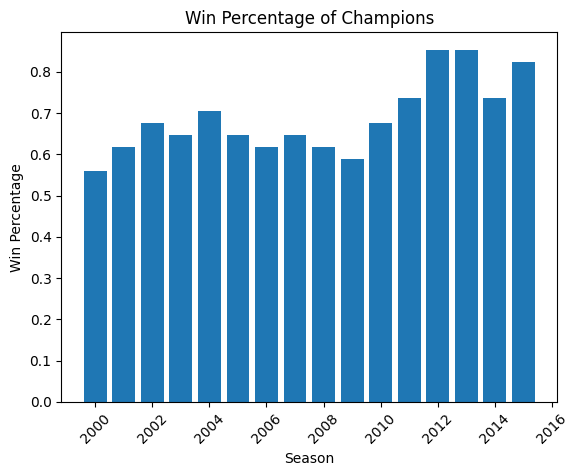

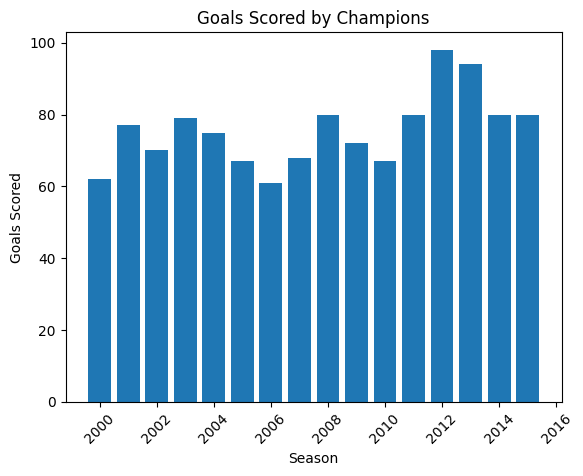

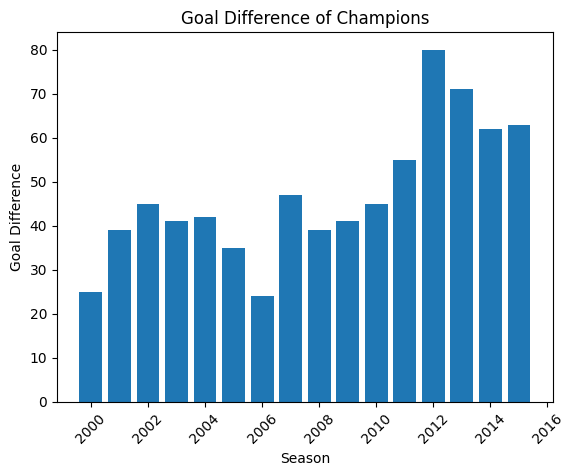

In [ ]:

# =========================

# =========================
df_champions_pd = df_champions.toPandas()

# =========================

# =========================
import matplotlib.pyplot as plt

# =========================
# 3. Win Percentage
# =========================
plt.figure()
plt.bar(df_champions_pd["Season"], df_champions_pd["WinPercentage"])
plt.title("Win Percentage of Champions")
plt.xlabel("Season")
plt.ylabel("Win Percentage")
plt.xticks(rotation=45)
plt.show()

# =========================
# 4. Goals Scored
# =========================
plt.figure()
plt.bar(df_champions_pd["Season"], df_champions_pd["GoalsScored"])
plt.title("Goals Scored by Champions")
plt.xlabel("Season")
plt.ylabel("Goals Scored")
plt.xticks(rotation=45)
plt.show()

# =========================
# 5. Goal Differentials
# =========================
plt.figure()
plt.bar(df_champions_pd["Season"], df_champions_pd["GoalDifferentials"])
plt.title("Goal Difference of Champions")
plt.xlabel("Season")
plt.ylabel("Goal Difference")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_final.toPandas()


,Season,Team,TotalHomeWin,TotalHomeLoss,TotalHomeTie,HomeScoredGoals,HomeAgainstGoals,TotalAwayWin,TotalAwayLoss,TotalAwayTie,...,GoalsScored,GoalsAgainst,Win,Loss,Tie,GoalDifferentials,WinPercentage,GoalsPerGame,GoalsAgainstPerGame,TeamPosition
0,2000,Bayern Munich,12,4,1,37,20,7,5,5,...,62,37,19,9,6,25,0.558824,1.823529,1.088235,1
1,2000,Schalke 04,12,1,4,36,13,6,7,4,...,65,35,18,8,8,30,0.529412,1.911765,1.029412,2
2,2000,Hertha,11,4,2,38,22,7,10,0,...,58,52,18,14,2,6,0.529412,1.705882,1.529412,3
3,2000,Leverkusen,10,5,2,30,16,7,6,4,...,54,40,17,11,6,14,0.500000,1.588235,1.176471,4
4,2000,Dortmund,9,4,4,34,20,7,4,6,...,62,42,16,8,10,20,0.470588,1.823529,1.235294,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2015,Darmstadt,2,9,6,15,29,7,5,5,...,38,53,9,14,11,-15,0.264706,1.117647,1.558824,14
284,2015,Hoffenheim,6,5,6,22,25,3,10,4,...,39,54,9,15,10,-15,0.264706,1.147059,1.588235,14
285,2015,Ein Frankfurt,6,5,6,22,24,3,11,3,...,34,52,9,16,9,-18,0.264706,1.000000,1.529412,16
286,2015,Stuttgart,6,10,1,22,32,3,9,5,...,50,75,9,19,6,-25,0.264706,1.470588,2.205882,17


In [ ]:

# =========================

df_export = df_final.toPandas()

# =========================

# =========================
df_export.to_csv("football_data.csv", index=False)

# =========================

# =========================
from google.colab import files

files.download("football_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# حفظ DataFrame كـ CSV
df_final.toPandas().to_csv("df_final.csv", index=False)

# تحميل الملف
files.download("df_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>